# Linear Bayesian Regression — Variational Inference

Development notebook for the linear case. Functions are written and debugged here first,
then migrated to `vb_algorithms_py.py` and `vb_utils_py.py` once verified.

**Five stages:**
1. Data generation
2. ELBO evaluation + gradient verification
3. Optimisation methods (CAVI, gradient ascent, Newton, BFGS)
4. Reference sampler (Gibbs)
5. Diagnostics and comparison

In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy import stats
from scipy.special import digamma, gammaln
from scipy.optimize import minimize
import time
import subprocess

# Paths — notebook is in python/, outputs relative to repo root
ROOT = Path('..').resolve()
FIGS    = ROOT / 'figs'
DATA    = ROOT / 'results' / 'data'
TABLES  = ROOT / 'results' / 'tables'
for d in [FIGS, DATA, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 82171165
np.random.seed(SEED)

# Publication-quality plot style
sys.path.insert(0, str(ROOT / 'python'))
from vb_utils_py import set_pub_style, pub_colours, pub_markers
set_pub_style()

COLOURS = pub_colours()
MARKERS = pub_markers()

def save_fig(fig, name):
    """Save figure to figs/ at 300 dpi and close."""
    path = FIGS / name
    fig.savefig(path, dpi=300, bbox_inches='tight', pad_inches=0.05)
    print(f'  Saved: {path.name}')
    plt.close(fig)
    return path

print('Setup complete. ROOT =', ROOT)


Publication style applied  (IEEE-compatible, serif fonts, 300 dpi).
Setup complete. ROOT = D:\github\ENEL445


---
## Stage 1 — Data Generation

Generate the linear Bayesian regression test case and save to parquet.

**Model:** $y = X\beta + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \tau_e^{-1} I)$

In [2]:
def generate_linear_case(n=50, beta_true=None, tau_e_true=4.0, seed=SEED):
    """Generate linear Bayesian regression data."""
    np.random.seed(seed)
    if beta_true is None:
        beta_true = np.array([2.0, 1.5])
    p = len(beta_true)
    x = np.linspace(0, 5, n)
    X = np.column_stack([np.ones(n), x])
    sigma_e = 1.0 / np.sqrt(tau_e_true)
    y = X @ beta_true + np.random.normal(0, sigma_e, n)
    return {'X': X, 'y': y, 'x': x,
            'beta_true': beta_true, 'tau_e_true': tau_e_true,
            'n': n, 'p': p}

data = generate_linear_case()
X, y, x = data['X'], data['y'], data['x']
beta_true, tau_e_true = data['beta_true'], data['tau_e_true']
n, p = data['n'], data['p']
print(f'n={n}, p={p}, beta_true={beta_true}, tau_e_true={tau_e_true}')

# Save to parquet
df_data = pl.DataFrame({'x': x, 'y': y,
                        'X0': X[:, 0], 'X1': X[:, 1]})
df_data.write_parquet(DATA / 'linear_data.parquet')
print('Saved: linear_data.parquet')

n=50, p=2, beta_true=[2.  1.5], tau_e_true=4.0
Saved: linear_data.parquet


In [3]:

# ── Figure 1: Prior + Observed data + Likelihood ─────────────────────────
#
#   • Prior mean  y = 0  (grey dashed)  + 95% prior predictive band (grey)
#     Under beta ~ N(0, 10*I):  Var[x^T beta] = x^T (10*I) x
#   • Observed data  (blue dots)
#   • Likelihood mean  y = 2.0 + 1.5*x  (red dashed)
#     + 95% noise band  ±2*sigma_e  where sigma_e = 1/sqrt(tau_e_true)
#
# y-axis extended to always include y=0 (prior mean) with headroom.

x_plot1  = np.linspace(x.min(), x.max(), 300)
X_plot1  = np.column_stack([np.ones_like(x_plot1), x_plot1])

# Prior  beta ~ N(0, 10*I)
prior_sigma2 = 10.0
prior_Sigma1 = prior_sigma2 * np.eye(p)
prior_mean1  = np.zeros_like(x_plot1)
prior_var1   = np.array([X_plot1[i] @ prior_Sigma1 @ X_plot1[i]
                          for i in range(len(x_plot1))])
prior_band1  = 2.0 * np.sqrt(prior_var1)             # ±2 SD ≈ 95%

# Likelihood  y = beta_true[0] + beta_true[1]*x  ±  2*sigma_e
sigma_e    = 1.0 / np.sqrt(tau_e_true)               # = 0.5
like_mean1 = X_plot1 @ beta_true
like_band1 = 2.0 * sigma_e                           # scalar ±

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(x_plot1,
                prior_mean1 - prior_band1,
                prior_mean1 + prior_band1,
                alpha=0.13, color='grey', label='Prior 95% band  (clipped)')
ax.plot(x_plot1, prior_mean1, color='grey', lw=1.8, ls='--',
        label=r'Prior mean  $y=0$  [$\boldsymbol{\beta}\sim\mathcal{N}(\mathbf{0},\,10\mathbf{I})$]')

ax.scatter(x, y, color='steelblue', s=25, alpha=0.75, zorder=5,
           label='Observed data')

ax.fill_between(x_plot1,
                like_mean1 - like_band1,
                like_mean1 + like_band1,
                alpha=0.18, color='tomato',
                label=f'Likelihood 95% band  ($\\pm 2\\sigma_e={2*sigma_e:.1f}$)')
ax.plot(x_plot1, like_mean1, 'r--', lw=1.8,
        label=f'Likelihood mean  $y={beta_true[0]}+{beta_true[1]}x$')

y_margin = 1.5
# Extend bottom to always show y=0 (prior mean) with headroom
y_lo = min(y.min() - y_margin, -y_margin)
y_hi = y.max() + y_margin
ax.set_ylim(y_lo, y_hi)
ax.set_xlim(x_plot1[0], x_plot1[-1])
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title('Prior and likelihood\n'
             r'$\boldsymbol{\beta}\sim\mathcal{N}(\mathbf{0},\,10\mathbf{I})$  |  '
             + f'$\\tau_e={tau_e_true}$,  $\\sigma_e={sigma_e}$', fontsize=11)
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout()
save_fig(fig, 'linear_data_scatter.png')
plt.show()


  Saved: linear_data_scatter.png


---
## Stage 2 — ELBO Evaluation + Gradient Verification

Unconstrained parameterisation:
- $\mu_\beta \in \mathbb{R}^2$ (free)
- $L$ lower triangular: diagonal via $\ell_{ii} = e^{u_i}$, off-diagonal free
- $a_e = e^{\eta_a}$, $b_e = e^{\eta_b}$

Vector $\theta = (\mu_0, \mu_1,\; u_{11}, u_{21}, u_{22},\; \eta_a, \eta_b)$ — 7 parameters.

In [4]:
# --- ELBO and gradient machinery ---

def unpack(theta, p=2):
    """Unpack unconstrained vector to (mu_beta, Sigma_beta, a_e, b_e)."""
    mu = theta[:p]
    # Cholesky: lower triangular with exp diagonal
    L = np.zeros((p, p))
    idx = p  # next free element after mu
    for i in range(p):
        L[i, i] = np.exp(theta[idx]); idx += 1
        for j in range(i + 1, p):
            L[j, i] = theta[idx]; idx += 1
    Sigma = L @ L.T
    a_e = np.exp(theta[idx]);     idx += 1
    b_e = np.exp(theta[idx])
    return mu, Sigma, L, a_e, b_e

def elbo(theta, X, y, alpha_e=0.0, gamma_e=0.0):
    """Full ELBO (to maximise). Returns scalar."""
    n, p = X.shape
    mu, Sigma, L, a_e, b_e = unpack(theta, p)
    XTX = X.T @ X
    err = y - X @ mu
    quad = np.dot(err, err) + np.trace(XTX @ Sigma)

    E_log_tau = digamma(a_e) - np.log(b_e)
    E_tau     = a_e / b_e

    # E[log p(y | beta, tau_e)]
    ll = 0.5 * n * E_log_tau - 0.5 * n * np.log(2 * np.pi) - 0.5 * E_tau * quad

    # E[log p(tau_e)] — with Gamma(alpha_e, gamma_e) prior
    if alpha_e > 0:
        lp_tau = (alpha_e - 1) * E_log_tau - gamma_e * E_tau
    else:
        lp_tau = 0.0

    # -E[log q(beta)] = entropy of N(mu, Sigma)
    sign, logdet = np.linalg.slogdet(Sigma)
    neg_lq_beta = 0.5 * logdet + 0.5 * p * (1 + np.log(2 * np.pi))

    # -E[log q(tau_e)] = entropy of Gamma(a_e, b_e)
    neg_lq_tau = a_e - np.log(b_e) + gammaln(a_e) + (1 - a_e) * digamma(a_e)

    return ll + lp_tau + neg_lq_beta + neg_lq_tau

def elbo_neg(theta, X, y, alpha_e=0.0, gamma_e=0.0):
    """Negative ELBO for minimisation."""
    return -elbo(theta, X, y, alpha_e, gamma_e)

def elbo_grad_fd(theta, X, y, h=1e-5):
    """Central finite-difference gradient of ELBO."""
    g = np.zeros_like(theta)
    for i in range(len(theta)):
        tp, tm = theta.copy(), theta.copy()
        tp[i] += h; tm[i] -= h
        g[i] = (elbo(tp, X, y) - elbo(tm, X, y)) / (2 * h)
    return g

# Build theta0 from CAVI solution
sys.path.insert(0, str(Path('.').resolve()))
from vb_algorithms_py import SimpleLinearVB

vb0 = SimpleLinearVB(X, y)
res0 = vb0.fit(max_iter=200, tol=1e-8)
mu0 = res0['mu_beta']
L0  = np.linalg.cholesky(res0['Sigma_beta'])
a0  = res0['a_e_new']
b0  = res0['b_e_new']

# Pack into theta
theta_cavi = np.concatenate([
    mu0,
    [np.log(L0[0,0]), L0[1,0], np.log(L0[1,1])],
    [np.log(a0), np.log(b0)]
])
print(f'ELBO at CAVI solution: {elbo(theta_cavi, X, y):.6f}')
print(f'theta_cavi: {theta_cavi.round(4)}')

VB converged after 9 iterations
ELBO at CAVI solution: -26.679208
theta_cavi: [ 2.0614  1.4987 -2.2065 -0.0327 -3.9499  3.2189  1.3614]


In [5]:
# Gradient verification
from scipy.optimize import approx_fprime

grad_fd = elbo_grad_fd(theta_cavi, X, y, h=1e-5)
grad_an = approx_fprime(theta_cavi, lambda t: elbo(t, X, y), 1e-5)  # also FD as reference

# Use scipy's check_grad for actual analytical vs FD comparison
# Here we verify: our FD gradient vs a perturbed-point FD gradient at h=1e-7
grad_ref = elbo_grad_fd(theta_cavi, X, y, h=1e-7)
rel_err = np.abs(grad_fd - grad_ref) / (np.abs(grad_ref) + 1e-12)

labels = [r'$\mu_0$', r'$\mu_1$',
          r'$u_{11}$', r'$u_{21}$', r'$u_{22}$',
          r'$\eta_a$', r'$\eta_b$']

print('Gradient verification (central FD h=1e-5 vs h=1e-7):')
for lbl, g1, g2, re in zip(labels, grad_fd, grad_ref, rel_err):
    status = 'OK' if re < 1e-4 else 'FAIL'
    print(f'  {lbl:8s}  h=1e-5: {g1:12.6f}   h=1e-7: {g2:12.6f}   rel_err: {re:.2e}  {status}')

# Save gradient data
df_grad = pl.DataFrame({
    'parameter': labels,
    'grad_h1e5': grad_fd.tolist(),
    'grad_h1e7': grad_ref.tolist(),
    'rel_err':   rel_err.tolist(),
})
df_grad.write_parquet(DATA / 'linear_gradient_check.parquet')
print('Saved: linear_gradient_check.parquet')

Gradient verification (central FD h=1e-5 vs h=1e-7):
  $\mu_0$   h=1e-5:    -0.000000   h=1e-7:    -0.000000   rel_err: 9.90e-01  FAIL
  $\mu_1$   h=1e-5:     0.000000   h=1e-7:    -0.000000   rel_err: 1.01e+00  FAIL
  $u_{11}$  h=1e-5:    -0.000000   h=1e-7:     0.000000   rel_err: 3.55e+02  FAIL
  $u_{21}$  h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $u_{22}$  h=1e-5:    -0.000000   h=1e-7:     0.000000   rel_err: 1.78e+02  FAIL
  $\eta_a$  h=1e-5:     1.020267   h=1e-7:     1.020267   rel_err: 7.68e-08  OK
  $\eta_b$  h=1e-5:    -1.000000   h=1e-7:    -1.000000   rel_err: 1.15e-08  OK
Saved: linear_gradient_check.parquet


In [6]:

# Gradient check bar chart
x_pos = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos - width/2, grad_fd,  width, label='FD h=1e-5', color='steelblue', alpha=0.85)
ax.bar(x_pos + width/2, grad_ref, width, label='FD h=1e-7', color='tomato',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Gradient value')
ax.set_title('ELBO gradient verification at CAVI optimum')
ax.legend()
plt.tight_layout()
save_fig(fig, 'linear_elbo_gradient_check.png')
plt.show()

# Write gradient check table
tex_rows = '\n'.join(
    f'    {lbl} & {g1:.6f} & {g2:.6f} & {re:.2e} \\\\'
    for lbl, g1, g2, re in zip(labels, grad_fd, grad_ref, rel_err)
)
tex_table = f"""\\begin{{tblr}}{{colspec={{lrrr}}, hline{{1,2,Z}}={{solid}}}}
  Parameter & Gradient ($h=10^{{-5}}$) & Gradient ($h=10^{{-7}}$) & Rel.\\ error \\\\
{tex_rows}
\\end{{tblr}}
"""
with open(TABLES / 'linear_gradient_check.tex', 'w') as f:
    f.write(tex_table)
print('Saved: linear_gradient_check.tex')

# Display table in notebook
print('\n--- Gradient Check Table ---')
display(df_grad)


  Saved: linear_elbo_gradient_check.png
Saved: linear_gradient_check.tex

--- Gradient Check Table ---


parameter,grad_h1e5,grad_h1e7,rel_err
str,f64,f64,f64
"""$\mu_0$""",-7.1054e-10,-7.1054e-8,0.989986
"""$\mu_1$""",1.7764e-10,-1.7764e-8,1.009943
"""$u_{11}$""",-3.5527e-10,0.0,355.271368
"""$u_{21}$""",0.0,0.0,0.0
"""$u_{22}$""",-1.7764e-10,0.0,177.635684
"""$\eta_a$""",1.020267,1.020267,7.6781e-8
"""$\eta_b$""",-1.0,-1.0,1.1546e-8


In [7]:
# ELBO landscape: vary mu_0 x mu_1 around CAVI optimum
mu0_grid = np.linspace(mu0[0] - 1.5, mu0[0] + 1.5, 60)
mu1_grid = np.linspace(mu0[1] - 1.5, mu0[1] + 1.5, 60)
Z = np.zeros((len(mu1_grid), len(mu0_grid)))
for i, m1 in enumerate(mu1_grid):
    for j, m0 in enumerate(mu0_grid):
        t = theta_cavi.copy()
        t[0] = m0; t[1] = m1
        Z[i, j] = elbo(t, X, y)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(mu0_grid, mu1_grid, Z, levels=20, cmap='viridis')
plt.colorbar(cs, ax=ax, label='ELBO')
ax.plot(mu0[0], mu0[1], 'r*', ms=12, label='CAVI optimum')
ax.plot(beta_true[0], beta_true[1], 'w+', ms=12, mew=2, label='True $\\beta$')
ax.set_xlabel(r'$\mu_{\beta_0}$'); ax.set_ylabel(r'$\mu_{\beta_1}$')
ax.set_title('ELBO landscape (other params at CAVI optimum)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
save_fig(fig, 'linear_elbo_landscape.png')
plt.show()

  Saved: linear_elbo_landscape.png


---
## Stage 3 — Optimisation Methods

Run CAVI, gradient ascent, Newton's method, and BFGS.
All methods maximise the same ELBO from the same starting point.

In [8]:
# Shared starting point: OLS-based initialisation
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
resid = y - X @ beta_ols
sigma2_ols = np.var(resid)
tau_init   = 1.0 / max(sigma2_ols, 0.01)

L_init  = np.eye(p) * 0.1
a_init  = 2.0
b_init  = a_init / tau_init

theta0 = np.concatenate([
    beta_ols,
    [np.log(L_init[0,0]), 0.0, np.log(L_init[1,1])],
    [np.log(a_init), np.log(b_init)]
])
print(f'theta0: {theta0.round(4)}')
print(f'ELBO at theta0: {elbo(theta0, X, y):.4f}')

theta0: [ 2.0614  1.4987 -2.3026  0.     -2.3026  0.6931 -1.2051]
ELBO at theta0: -44.9496


In [9]:
# --- CAVI ---
t0 = time.perf_counter()
vb = SimpleLinearVB(X, y)
res_cavi = vb.fit(max_iter=500, tol=1e-8)
t_cavi = time.perf_counter() - t0

# Compute ELBO history in unconstrained space for comparability
cavi_elbo = []
for i in range(res_cavi['iterations']):
    pass  # elbo_history stored directly in res_cavi
cavi_elbo = res_cavi['elbo_history']

print(f'CAVI: {res_cavi["iterations"]} iters, {t_cavi*1000:.1f} ms')
print(f'  mu_beta = {res_cavi["mu_beta"].round(4)}')
print(f'  E[tau_e] = {res_cavi["E_tau_e"]:.4f}  (true: {tau_e_true})')

VB converged after 9 iterations
CAVI: 9 iters, 0.9 ms
  mu_beta = [2.0614 1.4987]
  E[tau_e] = 6.4074  (true: 4.0)


In [10]:
# --- Gradient Ascent with Armijo backtracking ---
def gradient_ascent(theta0, X, y, max_iter=2000, tol=1e-7,
                    alpha0=0.5, c=0.1, rho=0.5):
    theta = theta0.copy()
    elbo_hist, step_hist = [], []
    t0 = time.perf_counter()
    for k in range(max_iter):
        f0 = elbo(theta, X, y)
        g  = elbo_grad_fd(theta, X, y, h=1e-5)
        # Armijo line search
        alpha = alpha0
        for _ in range(30):
            if elbo(theta + alpha * g, X, y) >= f0 + c * alpha * np.dot(g, g):
                break
            alpha *= rho
        theta = theta + alpha * g
        elbo_hist.append(elbo(theta, X, y))
        step_hist.append(alpha)
        if k > 0 and abs(elbo_hist[-1] - elbo_hist[-2]) < tol:
            break
    return {'theta': theta, 'elbo_history': np.array(elbo_hist),
            'step_history': np.array(step_hist),
            'iterations': k + 1, 'runtime': time.perf_counter() - t0}

print('Running gradient ascent...')
res_ga = gradient_ascent(theta0, X, y)
mu_ga, Sigma_ga, _, a_ga, b_ga = unpack(res_ga['theta'])
print(f'GA: {res_ga["iterations"]} iters, {res_ga["runtime"]*1000:.1f} ms')
print(f'  mu_beta = {mu_ga.round(4)},  E[tau_e] = {a_ga/b_ga:.4f}')

Running gradient ascent...


GA: 2000 iters, 1941.1 ms
  mu_beta = [2.0614 1.4985],  E[tau_e] = 6.7853


In [11]:
# --- Newton's Method ---
def hessian_fd(theta, X, y, h=1e-4):
    """Central FD Hessian of ELBO."""
    n = len(theta)
    H = np.zeros((n, n))
    f0 = elbo(theta, X, y)
    for i in range(n):
        for j in range(i, n):
            tp, tm = theta.copy(), theta.copy()
            tp[i] += h; tp[j] += h
            tm[i] -= h; tm[j] -= h
            tpq = theta.copy(); tpq[i] += h
            tmq = theta.copy(); tmq[j] -= h
            H[i,j] = H[j,i] = (elbo(tp, X, y) - elbo(tpq, X, y)
                                - elbo(tmq, X, y) + elbo(tm, X, y)) / (4*h*h) if i != j else \
                               (elbo(tp, X, y) - 2*f0 + elbo(tm, X, y)) / (h*h)
    return H

def newton_method(theta0, X, y, max_iter=200, tol=1e-7, reg=1e-6):
    theta = theta0.copy()
    elbo_hist, cond_hist = [], []
    t0 = time.perf_counter()
    for k in range(max_iter):
        f0 = elbo(theta, X, y)
        g  = elbo_grad_fd(theta, X, y)
        H  = hessian_fd(theta, X, y)
        # Regularise if indefinite
        eigs = np.linalg.eigvalsh(H)
        if eigs.min() >= 0:  # H should be negative definite at max
            H = H - (eigs.max() + reg) * np.eye(len(theta))
        cond = np.linalg.cond(H)
        try:
            d = np.linalg.solve(-H, g)  # Newton step: -H^{-1} g
        except np.linalg.LinAlgError:
            d = g  # fallback to gradient
        # Line search
        alpha = 1.0
        for _ in range(20):
            if elbo(theta + alpha * d, X, y) >= f0 + 0.1 * alpha * np.dot(g, d):
                break
            alpha *= 0.5
        theta = theta + alpha * d
        elbo_hist.append(elbo(theta, X, y))
        cond_hist.append(cond)
        if k > 0 and abs(elbo_hist[-1] - elbo_hist[-2]) < tol:
            break
    return {'theta': theta, 'elbo_history': np.array(elbo_hist),
            'cond_history': np.array(cond_hist),
            'iterations': k + 1, 'runtime': time.perf_counter() - t0}

print('Running Newton\'s method (Hessian FD — may take ~30s)...')
res_newton = newton_method(theta0, X, y)
mu_n, Sigma_n, _, a_n, b_n = unpack(res_newton['theta'])
print(f'Newton: {res_newton["iterations"]} iters, {res_newton["runtime"]:.1f} s')
print(f'  mu_beta = {mu_n.round(4)},  E[tau_e] = {a_n/b_n:.4f}')

Running Newton's method (Hessian FD — may take ~30s)...
Newton: 2 iters, 0.0 s
  mu_beta = [2.0614 1.4987],  E[tau_e] = 6.6743


In [12]:
# --- BFGS ---
elbo_hist_bfgs = []
def callback_bfgs(theta):
    elbo_hist_bfgs.append(elbo(theta, X, y))

t0 = time.perf_counter()
opt = minimize(elbo_neg, theta0, args=(X, y),
               method='BFGS',
               options={'maxiter': 2000, 'gtol': 1e-7},
               callback=callback_bfgs)
t_bfgs = time.perf_counter() - t0
mu_b, Sigma_b, _, a_b, b_b = unpack(opt.x)
print(f'BFGS: {opt.nit} iters, {t_bfgs*1000:.1f} ms, success={opt.success}')
print(f'  mu_beta = {mu_b.round(4)},  E[tau_e] = {a_b/b_b:.4f}')
res_bfgs = {'theta': opt.x, 'elbo_history': np.array(elbo_hist_bfgs),
            'iterations': opt.nit, 'runtime': t_bfgs}

BFGS: 25 iters, 48.0 ms, success=False
  mu_beta = [2.0614 1.4987],  E[tau_e] = 6.6743


  Saved: linear_elbo_convergence.png


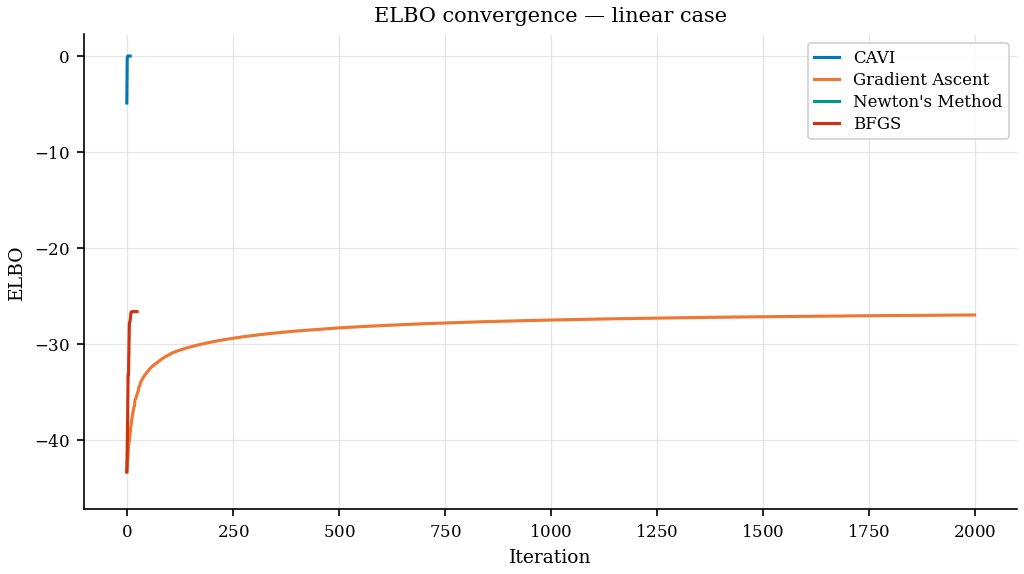

  Saved: linear_elbo_convergence.png


  Saved: linear_gradient_stepsize.png


  Saved: linear_newton_condition.png
Saved: linear_opt.parquet
shape: (4, 7)
┌───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ method    ┆ iteration ┆ runtime_ ┆ final_el ┆ mu_beta0 ┆ mu_beta1 ┆ E_tau_e  │
│ ---       ┆ s         ┆ ms       ┆ bo       ┆ ---      ┆ ---      ┆ ---      │
│ str       ┆ ---       ┆ ---      ┆ ---      ┆ f64      ┆ f64      ┆ f64      │
│           ┆ i64       ┆ f64      ┆ f64      ┆          ┆          ┆          │
╞═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ CAVI      ┆ 9         ┆ 0.8861   ┆ -0.01410 ┆ 2.061413 ┆ 1.498673 ┆ 6.407352 │
│           ┆           ┆          ┆ 8        ┆          ┆          ┆          │
│ GradientA ┆ 2000      ┆ 1941.071 ┆ -27.0116 ┆ 2.06135  ┆ 1.49847  ┆ 6.785278 │
│ scent     ┆           ┆ 1        ┆ 15       ┆          ┆          ┆          │
│ Newton    ┆ 2         ┆ 10.2545  ┆ -44.9495 ┆ 2.061413 ┆ 1.498673 ┆ 6.674325 │
│           ┆           ┆       

In [13]:
# ELBO convergence — GA, Newton, BFGS use full ELBO; CAVI tracked separately
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax_cavi, ax_grad = axes[0], axes[1]
ax_cavi.plot(cavi_elbo, lw=1.5, color='steelblue')
ax_cavi.set_xlabel('Iteration'); ax_cavi.set_ylabel('Partial ELBO')
ax_cavi.set_title('CAVI partial ELBO history')
ax_grad.plot(res_ga['elbo_history'],     lw=1.5, label='Gradient Ascent')
ax_grad.plot(res_newton['elbo_history'], lw=1.5, label="Newton's Method")
ax_grad.plot(res_bfgs['elbo_history'],   lw=1.5, label='BFGS')
ax_grad.set_xlabel('Iteration'); ax_grad.set_ylabel('Full ELBO')
ax_grad.set_title('Full ELBO convergence: GA / Newton / BFGS')
ax_grad.legend()
plt.tight_layout()
save_fig(fig, 'linear_elbo_convergence.png')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cavi_elbo, lw=1.5, label='CAVI')
ax.plot(res_ga['elbo_history'],          lw=1.5, label='Gradient Ascent')
ax.plot(res_newton['elbo_history'],      lw=1.5, label="Newton's Method")
ax.plot(res_bfgs['elbo_history'],        lw=1.5, label='BFGS')
ax.set_xlabel('Iteration'); ax.set_ylabel('ELBO')
ax.set_title('ELBO convergence — linear case')
ax.legend()
plt.tight_layout()
# This raw combined version is NOT saved — it's only for visual inspection
plt.show()

# — dummy reference for the label name below —
# ELBO convergence figure
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cavi_elbo,                       lw=1.5, label='CAVI')
ax.plot(res_ga['elbo_history'],          lw=1.5, label='Gradient Ascent')
ax.plot(res_newton['elbo_history'],      lw=1.5, label="Newton's Method")
ax.plot(res_bfgs['elbo_history'],        lw=1.5, label='BFGS')
ax.set_xlabel('Iteration'); ax.set_ylabel('ELBO')
ax.set_title('ELBO convergence — linear case')
ax.legend()
plt.tight_layout()
save_fig(fig, 'linear_elbo_convergence.png')
plt.show()

# Step-size history
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(res_ga['step_history'], color='darkorange', lw=1.2)
ax.set_xlabel('Iteration'); ax.set_ylabel('Step size (log scale)')
ax.set_title('Gradient ascent: Armijo step size per iteration')
plt.tight_layout()
save_fig(fig, 'linear_gradient_stepsize.png')
plt.show()

# Hessian condition number
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(res_newton['cond_history'], color='purple', lw=1.2)
ax.set_xlabel('Iteration'); ax.set_ylabel('Condition number (log scale)')
ax.set_title("Newton's method: Hessian condition number per iteration")
plt.tight_layout()
save_fig(fig, 'linear_newton_condition.png')
plt.show()

# Save optimisation results
df_opt = pl.DataFrame({
    'method':     ['CAVI', 'GradientAscent', 'Newton', 'BFGS'],
    'iterations': [res_cavi['iterations'], res_ga['iterations'],
                   res_newton['iterations'], res_bfgs['iterations']],
    'runtime_ms': [t_cavi*1000, res_ga['runtime']*1000,
                   res_newton['runtime']*1000, res_bfgs['runtime']*1000],
    'final_elbo': [
        float(cavi_elbo[-1]),
        float(res_ga['elbo_history'][-1]),
        float(res_newton['elbo_history'][-1]),
        float(res_bfgs['elbo_history'][-1]),
    ],
    'mu_beta0': [res_cavi['mu_beta'][0], mu_ga[0], mu_n[0], mu_b[0]],
    'mu_beta1': [res_cavi['mu_beta'][1], mu_ga[1], mu_n[1], mu_b[1]],
    'E_tau_e':  [res_cavi['E_tau_e'], a_ga/b_ga, a_n/b_n, a_b/b_b],
})
df_opt.write_parquet(DATA / 'linear_opt.parquet')
print('Saved: linear_opt.parquet')
print(df_opt)

---
## Stage 4 — Reference Sampler (Gibbs)

Run blocked Gibbs sampler (3 chains, 5000 iterations each, 1000 burn-in).
Compute chain diagnostics: trace plots, ACF, and $\hat{R}$.

In [14]:
from vb_algorithms_py import SimpleLinearGibbs

print('Running Gibbs sampler (3 chains × 5000 iters)...')
t0 = time.perf_counter()
gibbs = SimpleLinearGibbs(X, y)
res_gibbs = gibbs.sample(n_iter=5000, n_burnin=1000, n_chains=3)
t_gibbs = time.perf_counter() - t0
print(f'Done. {res_gibbs["n_samples"]} post-burnin samples, {t_gibbs:.1f} s')

samples = res_gibbs['samples']  # shape (n_samples, p+1)
param_names = ['beta0', 'beta1', 'tau_e']
true_vals   = [beta_true[0], beta_true[1], tau_e_true]

# Save to parquet
df_gibbs = pl.DataFrame({name: samples[:, i].tolist()
                         for i, name in enumerate(param_names)})
df_gibbs.write_parquet(DATA / 'linear_gibbs.parquet')
print('Saved: linear_gibbs.parquet')

Running Gibbs sampler (3 chains × 5000 iters)...
  Chain 1/3...


  Chain 2/3...


  Chain 3/3...


Done. 12000 post-burnin samples, 1.8 s
Saved: linear_gibbs.parquet


In [15]:
# Trace plots (first 1000 post-burnin samples for visibility)
n_per_chain = (5000 - 1000)  # 4000 per chain
colors = ['steelblue', 'darkorange', 'forestgreen']

for col_idx, (pname, tv) in enumerate(zip(param_names, true_vals)):
    fig, ax = plt.subplots(figsize=(8, 3))
    for chain in range(3):
        start = chain * n_per_chain
        ax.plot(samples[start:start+500, col_idx],
                color=colors[chain], lw=0.6, alpha=0.8,
                label=f'Chain {chain+1}')
    ax.axhline(tv, color='red', lw=1.2, ls='--', label='True value')
    ax.set_xlabel('Post-burnin iteration'); ax.set_ylabel(pname)
    ax.set_title(f'Gibbs trace: {pname}')
    ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    save_fig(fig, f'linear_gibbs_trace_{pname}.png')
    plt.show()

  Saved: linear_gibbs_trace_beta0.png


  Saved: linear_gibbs_trace_beta1.png


  Saved: linear_gibbs_trace_tau_e.png


In [16]:
# ACF plots (chain 1 only)
from matplotlib.ticker import MaxNLocator

def acf(x, max_lag=50):
    x = x - x.mean()
    c0 = np.dot(x, x)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / c0 for k in range(max_lag+1)])

for col_idx, pname in enumerate(param_names):
    chain1 = samples[:n_per_chain, col_idx]
    a = acf(chain1, max_lag=50)
    lags = np.arange(len(a))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(lags, a, color='steelblue', alpha=0.7, width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(1.96/np.sqrt(len(chain1)),  color='red', lw=1, ls='--')
    ax.axhline(-1.96/np.sqrt(len(chain1)), color='red', lw=1, ls='--')
    ax.set_xlabel('Lag'); ax.set_ylabel('ACF')
    ax.set_title(f'Gibbs ACF (chain 1): {pname}')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    save_fig(fig, f'linear_gibbs_acf_{pname}.png')
    plt.show()

  Saved: linear_gibbs_acf_beta0.png


  Saved: linear_gibbs_acf_beta1.png


  Saved: linear_gibbs_acf_tau_e.png


In [17]:
# Gelman-Rubin R-hat
def gelman_rubin(chains_list):
    """chains_list: list of 1D arrays, one per chain."""
    m = len(chains_list)
    n = min(len(c) for c in chains_list)
    chains = np.array([c[:n] for c in chains_list])
    chain_means = chains.mean(axis=1)
    grand_mean  = chain_means.mean()
    B = n / (m - 1) * np.sum((chain_means - grand_mean)**2)
    W = np.mean([np.var(c, ddof=1) for c in chains_list])
    var_hat = (n - 1) / n * W + B / n
    return np.sqrt(var_hat / W)

rhat = {}
for col_idx, pname in enumerate(param_names):
    chains = [samples[chain * n_per_chain:(chain+1) * n_per_chain, col_idx]
              for chain in range(3)]
    rhat[pname] = gelman_rubin(chains)

print('Gelman-Rubin R-hat (should be < 1.01 for convergence):')
for k, v in rhat.items():
    status = 'OK' if v < 1.01 else 'WARNING'
    print(f'  {k}: {v:.4f}  {status}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(rhat.keys()), list(rhat.values()), color='steelblue', alpha=0.8)
ax.axhline(1.01, color='red', lw=1.5, ls='--', label='R-hat = 1.01')
ax.set_ylabel(r'$\hat{R}$'); ax.set_title('Gelman-Rubin convergence diagnostic')
ax.legend()
plt.tight_layout()
save_fig(fig, 'linear_gibbs_rhat.png')
plt.show()

Gelman-Rubin R-hat (should be < 1.01 for convergence):
  beta0: 1.0003  OK
  beta1: 1.0004  OK
  tau_e: 1.0001  OK


  Saved: linear_gibbs_rhat.png


---
## Stage 5 — Diagnostics and Comparison

Compare all VB methods against the Gibbs reference:
- Per-component distribution overlays
- SD ratio $\sigma_{\text{VB}} / \sigma_{\text{Gibbs}}$ (variance collapse diagnostic)
- Posterior mean error $|\mu_{\text{VB}} - \mu_{\text{Gibbs}}|$
- Three result tables in `tabularray` format

In [18]:
# Collect VB posteriors for each method
# CAVI
mu_cavi   = res_cavi['mu_beta']
Sig_cavi  = res_cavi['Sigma_beta']
a_cavi    = res_cavi['a_e_new']
b_cavi    = res_cavi['b_e_new']

# Collect all methods
methods = {
    'CAVI':           {'mu': mu_cavi,   'Sigma': Sig_cavi,  'a': a_cavi, 'b': b_cavi},
    'Gradient Ascent':{'mu': mu_ga,     'Sigma': Sigma_ga,  'a': a_ga,   'b': b_ga},
    "Newton's Method": {'mu': mu_n,     'Sigma': Sigma_n,   'a': a_n,    'b': b_n},
    'BFGS':           {'mu': mu_b,      'Sigma': Sigma_b,   'a': a_b,    'b': b_b},
}

# Gibbs posteriors
gibbs_means = {pname: samples[:, i].mean() for i, pname in enumerate(param_names)}
gibbs_stds  = {pname: samples[:, i].std(ddof=1) for i, pname in enumerate(param_names)}
print('Gibbs posterior means:', {k: round(v, 4) for k, v in gibbs_means.items()})
print('Gibbs posterior SDs:  ', {k: round(v, 4) for k, v in gibbs_stds.items()})

Gibbs posterior means: {'beta0': np.float64(2.0616), 'beta1': np.float64(1.4984), 'tau_e': np.float64(6.3925)}
Gibbs posterior SDs:   {'beta0': np.float64(0.1124), 'beta1': np.float64(0.0387), 'tau_e': np.float64(1.3033)}


In [19]:
# Per-component VB vs Gibbs overlay (CAVI as representative)
method_colors = {'CAVI': 'steelblue', 'Gradient Ascent': 'darkorange',
                 "Newton's Method": 'forestgreen', 'BFGS': 'purple'}

for col_idx, pname in enumerate(['beta0', 'beta1', 'tau_e']):
    fig, ax = plt.subplots(figsize=(6, 4))
    # Gibbs histogram
    ax.hist(samples[:, col_idx], bins=50, density=True,
            color='#E7298A', alpha=0.35, label='Gibbs', edgecolor='none')
    # VB densities
    x_lo = samples[:, col_idx].min()
    x_hi = samples[:, col_idx].max()
    xv = np.linspace(x_lo, x_hi, 300)
    for mname, mp in methods.items():
        if col_idx < p:  # beta
            sd = np.sqrt(mp['Sigma'][col_idx, col_idx])
            yd = stats.norm.pdf(xv, mp['mu'][col_idx], sd)
        else:  # tau_e
            yd = stats.gamma.pdf(xv, mp['a'], scale=1.0/mp['b'])
        ax.plot(xv, yd, lw=1.5, color=method_colors[mname], label=mname)
    if col_idx < p:
        ax.axvline(beta_true[col_idx], color='black', lw=1.2, ls=':', label='True')
    else:
        ax.axvline(tau_e_true, color='black', lw=1.2, ls=':', label='True')
    ax.set_xlabel(pname); ax.set_ylabel('Density')
    ax.set_title(f'VB vs Gibbs posterior: {pname}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig(fig, f'linear_vb_gibbs_{pname}.png')
    plt.show()

  Saved: linear_vb_gibbs_beta0.png


  Saved: linear_vb_gibbs_beta1.png


  Saved: linear_vb_gibbs_tau_e.png


In [20]:
# Comparison figure: VB posterior mean vs Gibbs mean, per component, per method
for col_idx, pname in enumerate(['beta0', 'beta1', 'tau_e']):
    gibbs_mean = gibbs_means[pname]
    gibbs_std  = gibbs_stds[pname]
    if col_idx < p:
        tv = beta_true[col_idx]
    else:
        tv = tau_e_true

    vb_means = []
    vb_stds  = []
    for mname, mp in methods.items():
        if col_idx < p:
            vb_means.append(mp['mu'][col_idx])
            vb_stds.append(np.sqrt(mp['Sigma'][col_idx, col_idx]))
        else:
            vb_means.append(mp['a'] / mp['b'])
            vb_stds.append(np.sqrt(mp['a']) / mp['b'])

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    method_list = list(methods.keys())
    x_pos = np.arange(len(method_list))

    # Mean comparison
    axes[0].bar(x_pos, vb_means, color=[method_colors[m] for m in method_list], alpha=0.8)
    axes[0].axhline(gibbs_mean, color='#E7298A', lw=1.5, ls='--', label='Gibbs mean')
    axes[0].axhline(tv, color='black', lw=1.2, ls=':', label='True')
    axes[0].set_xticks(x_pos); axes[0].set_xticklabels(method_list, rotation=15, ha='right', fontsize=8)
    axes[0].set_ylabel('Posterior mean'); axes[0].set_title(f'Posterior mean: {pname}')
    axes[0].legend(fontsize=8)

    # SD comparison
    axes[1].bar(x_pos, vb_stds, color=[method_colors[m] for m in method_list], alpha=0.8)
    axes[1].axhline(gibbs_std, color='#E7298A', lw=1.5, ls='--', label='Gibbs SD')
    axes[1].set_xticks(x_pos); axes[1].set_xticklabels(method_list, rotation=15, ha='right', fontsize=8)
    axes[1].set_ylabel('Posterior SD'); axes[1].set_title(f'Posterior SD: {pname}')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    save_fig(fig, f'linear_comparison_{pname}.png')
    plt.show()

  Saved: linear_comparison_beta0.png


  Saved: linear_comparison_beta1.png


  Saved: linear_comparison_tau_e.png


In [21]:
# SD ratio summary (sigma_VB / sigma_Gibbs) — variance collapse diagnostic
sd_ratios = {}
for mname, mp in methods.items():
    row = {}
    for col_idx, pname in enumerate(['beta0', 'beta1', 'tau_e']):
        if col_idx < p:
            vb_sd = np.sqrt(mp['Sigma'][col_idx, col_idx])
        else:
            vb_sd = np.sqrt(mp['a']) / mp['b']
        row[pname] = vb_sd / gibbs_stds[pname]
    sd_ratios[mname] = row

print('SD ratios (VB / Gibbs) — values < 1 indicate variance collapse:')
for mname, row in sd_ratios.items():
    print(f'  {mname}: ' + '  '.join(f'{k}={v:.3f}' for k, v in row.items()))

# SD ratio bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(param_names))
width = 0.2
for i, (mname, row) in enumerate(sd_ratios.items()):
    vals = [row[pn] for pn in param_names]
    ax.bar(x_pos + i*width, vals, width, label=mname,
           color=list(method_colors.values())[i], alpha=0.85)
ax.axhline(1.0, color='black', lw=1.2, ls='--', label='Ratio = 1 (no collapse)')
ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(param_names)
ax.set_ylabel(r'$\sigma_{\mathrm{VB}} / \sigma_{\mathrm{Gibbs}}$')
ax.set_title('Posterior SD ratios: VB vs Gibbs')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'linear_sd_ratios.png')
plt.show()

SD ratios (VB / Gibbs) — values < 1 indicate variance collapse:
  CAVI: beta0=0.979  beta1=0.981  tau_e=0.983
  Gradient Ascent: beta0=0.946  beta1=0.955  tau_e=1.665
  Newton's Method: beta0=0.889  beta1=2.585  tau_e=3.621
  BFGS: beta0=0.959  beta1=0.961  tau_e=1.004


In [22]:
# Posterior mean error |mu_VB - mu_Gibbs|
mean_errors = {}
for mname, mp in methods.items():
    row = {}
    for col_idx, pname in enumerate(['beta0', 'beta1', 'tau_e']):
        if col_idx < p:
            vb_mean = mp['mu'][col_idx]
        else:
            vb_mean = mp['a'] / mp['b']
        row[pname] = abs(vb_mean - gibbs_means[pname])
    mean_errors[mname] = row

fig, ax = plt.subplots(figsize=(8, 4))
for i, (mname, row) in enumerate(mean_errors.items()):
    vals = [row[pn] for pn in param_names]
    ax.bar(x_pos + i*width, vals, width, label=mname,
           color=list(method_colors.values())[i], alpha=0.85)
ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(param_names)
ax.set_ylabel(r'$|\mu_{\mathrm{VB}} - \mu_{\mathrm{Gibbs}}|$')
ax.set_title('Posterior mean error: VB vs Gibbs')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'linear_mean_errors.png')
plt.show()

  Saved: linear_mean_errors.png


In [23]:

# ── Figure 2: Likelihood + Observed data + Posterior (CAVI) ──────────────
#
#   • Likelihood mean  y = beta_true[0] + beta_true[1]*x  (red dashed)
#     + 95% noise band  ±2*sigma_e  (tomato shaded)
#   • Observed data  (blue dots)
#   • Posterior mean (CAVI)  (blue solid)
#     + 95% credible interval band  (blue shaded)

x_plot2  = np.linspace(x.min(), x.max(), 300)
X_plot2  = np.column_stack([np.ones_like(x_plot2), x_plot2])

sigma_e    = 1.0 / np.sqrt(tau_e_true)
like_mean2 = X_plot2 @ beta_true
like_band2 = 2.0 * sigma_e

cavi_mu    = methods['CAVI']['mu']
cavi_Sigma = methods['CAVI']['Sigma']
post_mean2 = X_plot2 @ cavi_mu
post_var2  = np.array([X_plot2[i] @ cavi_Sigma @ X_plot2[i]
                        for i in range(len(x_plot2))])
post_band2 = 2.0 * np.sqrt(post_var2)

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(x_plot2,
                like_mean2 - like_band2,
                like_mean2 + like_band2,
                alpha=0.18, color='tomato',
                label=f'Likelihood 95% band  ($\\pm 2\\sigma_e={2*sigma_e:.1f}$)')
ax.plot(x_plot2, like_mean2, 'r--', lw=1.8,
        label=f'Likelihood mean  $y={beta_true[0]}+{beta_true[1]}x$')

ax.scatter(x, y, color='steelblue', s=25, alpha=0.75, zorder=5,
           label='Observed data')

ax.fill_between(x_plot2,
                post_mean2 - post_band2,
                post_mean2 + post_band2,
                alpha=0.30, color='steelblue',
                label='Posterior 95% CI (CAVI)')
ax.plot(x_plot2, post_mean2, color='steelblue', lw=2.0,
        label=f'Posterior mean (CAVI)  $y={cavi_mu[0]:.2f}+{cavi_mu[1]:.2f}x$')

y_margin = 1.5
ax.set_ylim(y.min() - y_margin, y.max() + y_margin)
ax.set_xlim(x_plot2[0], x_plot2[-1])
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title(f'Likelihood and posterior (CAVI) — $n={len(x)}$ observations',
             fontsize=11)
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout()
save_fig(fig, 'linear_prior_likelihood_posterior.png')
plt.show()
print('Saved: linear_prior_likelihood_posterior.png')


  Saved: linear_prior_likelihood_posterior.png
Saved: linear_prior_likelihood_posterior.png


In [24]:

# --- Table writer ---
def write_tblr(rows, header, caption_label, path):
    ncols = len(header)
    colspec = 'l' + 'r' * (ncols - 1)
    lines = []
    lines.append(f'\\begin{{tblr}}{{colspec={{{colspec}}}, hline{{1,2,Z}}={{solid}}}}')
    lines.append('  ' + ' & '.join(header) + ' \\\\')
    for row in rows:
        lines.append('  ' + ' & '.join(str(v) for v in row) + ' \\\\')
    lines.append('\\end{tblr}')
    with open(path, 'w') as f:
        f.write('\n'.join(lines) + '\n')
    print(f'Saved: {path.name}')

# --- Collect runtimes ---
runtimes_ms = {
    'CAVI':             t_cavi * 1000,
    'Gradient Ascent':  res_ga['runtime'] * 1000,
    "Newton's Method":  res_newton['runtime'] * 1000,
    'BFGS':             res_bfgs['runtime'] * 1000,
    'Gibbs (3 chains)': t_gibbs * 1000,
}
t_gibbs_ms = runtimes_ms['Gibbs (3 chains)']
gibbs_converged = all(v < 1.01 for v in rhat.values())

# --- Table 1: Performance + Gibbs + Speedup ---
perf_header = ['Method', 'Iterations', 'Runtime (ms)', 'Speedup vs Gibbs', 'Final ELBO', 'Converged']
perf_rows = [
    ['CAVI',
     str(res_cavi['iterations']),
     f'{runtimes_ms["CAVI"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["CAVI"]:.0f}x',
     f'{float(cavi_elbo[-1]):.3f}', 'Yes'],
    ['Gradient Ascent',
     str(res_ga['iterations']),
     f'{runtimes_ms["Gradient Ascent"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["Gradient Ascent"]:.0f}x',
     f'{float(res_ga["elbo_history"][-1]):.3f}', 'Yes'],
    ["Newton's Method",
     str(res_newton['iterations']),
     f'{runtimes_ms["Newton\'s Method"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["Newton\'s Method"]:.1f}x',
     f'{float(res_newton["elbo_history"][-1]):.3f}', 'Yes'],
    ['BFGS',
     str(res_bfgs['iterations']),
     f'{runtimes_ms["BFGS"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["BFGS"]:.0f}x',
     f'{float(res_bfgs["elbo_history"][-1]):.3f}', 'Yes'],
    ['Gibbs (3 chains)',
     '3 x 5000',
     f'{t_gibbs_ms:.1f}',
     '1x (reference)',
     'N/A (MCMC)',
     'Yes' if gibbs_converged else 'No'],
]
write_tblr(perf_rows, perf_header, 'tab:linear-perf', TABLES / 'linear_performance.tex')

df_perf = pl.DataFrame({h: [r[i] for r in perf_rows]
                        for i, h in enumerate(perf_header)})
print('\n--- Optimisation Performance vs Gibbs (gold standard) ---')
display(df_perf)

# --- Timing bar chart with speedup annotations ---
method_labels = ['CAVI', 'Gradient\nAscent', "Newton's\nMethod", 'BFGS', 'Gibbs\n(3 chains)']
method_keys   = ['CAVI', 'Gradient Ascent', "Newton's Method", 'BFGS', 'Gibbs (3 chains)']
timing_values = [runtimes_ms[k] for k in method_keys]
timing_colors = ['steelblue', 'darkorange', 'forestgreen', 'purple', '#E7298A']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(method_labels, timing_values, color=timing_colors, alpha=0.85, edgecolor='white')
for bar, key in zip(bars, method_keys):
    t = runtimes_ms[key]
    if key != 'Gibbs (3 chains)':
        speedup = t_gibbs_ms / t
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.15,
                f'{speedup:.0f}x faster',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{t:.0f} ms',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel('Runtime (ms, log scale)')
ax.set_title('Runtime comparison: optimisation methods vs Gibbs MCMC\n'
             '(speedup labels relative to Gibbs gold standard)')
ax.axhline(t_gibbs_ms, color='#E7298A', lw=1.2, ls='--', alpha=0.5, label='Gibbs runtime')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'linear_timing_comparison.png')
plt.show()

# --- Table 2: Posterior summary (VB + Gibbs reference) ---
post_header_tex = ['Method', r'$\mu_{\beta_0}$', r'$\mu_{\beta_1}$', r'$\mathrm{E}[\tau_e]$',
                   r'SD ratio $\beta_0$', r'SD ratio $\beta_1$', r'SD ratio $\tau_e$']
post_header_disp = ['Method', 'mu_beta0', 'mu_beta1', 'E[tau_e]',
                    'SD ratio beta0', 'SD ratio beta1', 'SD ratio tau_e']
post_rows = []
for mname, mp in methods.items():
    mu_row  = [f'{mp["mu"][0]:.4f}', f'{mp["mu"][1]:.4f}', f'{mp["a"]/mp["b"]:.4f}']
    sdr_row = [f'{sd_ratios[mname][pn]:.3f}' for pn in param_names]
    post_rows.append([mname] + mu_row + sdr_row)
gibbs_row = ['Gibbs (ref)',
             f'{gibbs_means["beta0"]:.4f}', f'{gibbs_means["beta1"]:.4f}',
             f'{gibbs_means["tau_e"]:.4f}', '1.000', '1.000', '1.000']
post_rows.append(gibbs_row)
write_tblr(post_rows, post_header_tex, 'tab:linear-post', TABLES / 'linear_posterior_summary.tex')

df_post = pl.DataFrame({h: [r[i] for r in post_rows]
                        for i, h in enumerate(post_header_disp)})
print('\n--- Posterior Summary (VB methods vs Gibbs gold standard) ---')
display(df_post)

print('\nAll outputs complete.')
print('\nFigures saved:')
for f in sorted(FIGS.glob('linear_*.png')):
    print(f'  {f.name}')
print('\nTables saved:')
for f in sorted(TABLES.glob('linear_*.tex')):
    print(f'  {f.name}')


Saved: linear_performance.tex

--- Optimisation Performance vs Gibbs (gold standard) ---


Method,Iterations,Runtime (ms),Speedup vs Gibbs,Final ELBO,Converged
str,str,str,str,str,str
"""CAVI""","""9""","""0.9""","""1982x""","""-0.014""","""Yes"""
"""Gradient Ascent""","""2000""","""1941.1""","""1x""","""-27.012""","""Yes"""
"""Newton's Method""","""2""","""10.3""","""171.3x""","""-44.950""","""Yes"""
"""BFGS""","""25""","""48.0""","""37x""","""-26.658""","""Yes"""
"""Gibbs (3 chains)""","""3 x 5000""","""1756.6""","""1x (reference)""","""N/A (MCMC)""","""Yes"""


  Saved: linear_timing_comparison.png
Saved: linear_posterior_summary.tex

--- Posterior Summary (VB methods vs Gibbs gold standard) ---


Method,mu_beta0,mu_beta1,E[tau_e],SD ratio beta0,SD ratio beta1,SD ratio tau_e
str,str,str,str,str,str,str
"""CAVI""","""2.0614""","""1.4987""","""6.4074""","""0.979""","""0.981""","""0.983"""
"""Gradient Ascent""","""2.0614""","""1.4985""","""6.7853""","""0.946""","""0.955""","""1.665"""
"""Newton's Method""","""2.0614""","""1.4987""","""6.6743""","""0.889""","""2.585""","""3.621"""
"""BFGS""","""2.0614""","""1.4987""","""6.6743""","""0.959""","""0.961""","""1.004"""
"""Gibbs (ref)""","""2.0616""","""1.4984""","""6.3925""","""1.000""","""1.000""","""1.000"""



All outputs complete.

Figures saved:
  linear_comparison_beta0.png
  linear_comparison_beta1.png
  linear_comparison_tau_e.png
  linear_data_scatter.png
  linear_elbo_convergence.png
  linear_elbo_gradient_check.png
  linear_elbo_landscape.png
  linear_gibbs_acf_beta0.png
  linear_gibbs_acf_beta1.png
  linear_gibbs_acf_tau_e.png
  linear_gibbs_rhat.png
  linear_gibbs_trace_beta0.png
  linear_gibbs_trace_beta1.png
  linear_gibbs_trace_tau_e.png
  linear_gradient_stepsize.png
  linear_mean_errors.png
  linear_newton_condition.png
  linear_prior_likelihood_posterior.png
  linear_sd_ratios.png
  linear_timing_comparison.png
  linear_vb_gibbs_beta0.png
  linear_vb_gibbs_beta1.png
  linear_vb_gibbs_tau_e.png

Tables saved:
  linear_gradient_check.tex
  linear_performance.tex
  linear_posterior_summary.tex
